In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
DATA_DIR = "/content/drive/MyDrive/data1"
SAVE_DIR = "/content/drive/MyDrive/models1"
os.makedirs(SAVE_DIR, exist_ok=True)
if os.path.exists(DATA_DIR):
    print("✅ Drive Mounted & Data Folder Found!")
    print("Folders:", os.listdir(DATA_DIR))
else:
    print("❌ ERROR: Path not found. Check your DATA_DIR address.")

✅ Drive Mounted & Data Folder Found!
Folders: ['validation', 'test', 'train']


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import copy
from google.colab import drive

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

image_datasets = {
    "train": datasets.ImageFolder(os.path.join(DATA_DIR, "train"), train_transform),
    "validation": datasets.ImageFolder(os.path.join(DATA_DIR, "validation"), val_transform)
}

loaders = {
    "train": DataLoader(image_datasets["train"], batch_size=32, shuffle=True, num_workers=2,pin_memory=True),
    "validation": DataLoader(image_datasets["validation"], batch_size=32, shuffle=False, num_workers=2,pin_memory=True)
}

class_names = image_datasets["train"].classes
print(f"Ready to train on classes: {class_names}")

Ready to train on classes: ['normal', 'tumor']


In [4]:
# 1. Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# 2. Model builder
def build_model(name, num_classes):
    if name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif name == "densenet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    else:
        raise ValueError("Invalid model name")

    return model.to(DEVICE)

Using device: cuda


In [5]:
def get_clipping_bounds(device):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1).to(device)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1).to(device)

    min_clip = (0 - mean) / std
    max_clip = (1 - mean) / std

    return min_clip, max_clip

def fgsm_attack(model, images, labels, epsilon, min_clip, max_clip):

    images = images.clone().detach().to(DEVICE)
    images.requires_grad_(True)

    outputs = model(images)
    loss = nn.CrossEntropyLoss()(outputs, labels)

    model.zero_grad(set_to_none=True)
    loss.backward()

    grad = images.grad.sign()

    adv_images = images + epsilon * grad

    adv_images = torch.max(
        torch.min(adv_images, max_clip),
        min_clip
    )

    return adv_images.detach()


TRAINING ADVERSARIAL MODEL: densenet121
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 175MB/s]
Epoch 1 [Train]: 100%|██████████| 62/62 [05:12<00:00,  5.05s/it]


Result -> Train Acc: 0.9505 | Val Acc: 0.9643
 Saved New Best: /content/drive/MyDrive/models1/tumor_densenet121_adv.pth


Epoch 2 [Train]: 100%|██████████| 62/62 [01:02<00:00,  1.00s/it]


Result -> Train Acc: 0.9699 | Val Acc: 0.9738
 Saved New Best: /content/drive/MyDrive/models1/tumor_densenet121_adv.pth


...

Result -> Train Acc: 0.9842 | Val Acc: 0.9798


Epoch 9 [Train]: 100%|██████████| 62/62 [01:03<00:00,  1.02s/it]


Result -> Train Acc: 0.9867 | Val Acc: 0.9833
 Saved New Best: /content/drive/MyDrive/models1/tumor_densenet121_adv.pth


Epoch 10 [Train]: 100%|██████████| 62/62 [01:03<00:00,  1.02s/it]


Result -> Train Acc: 0.9918 | Val Acc: 0.9786


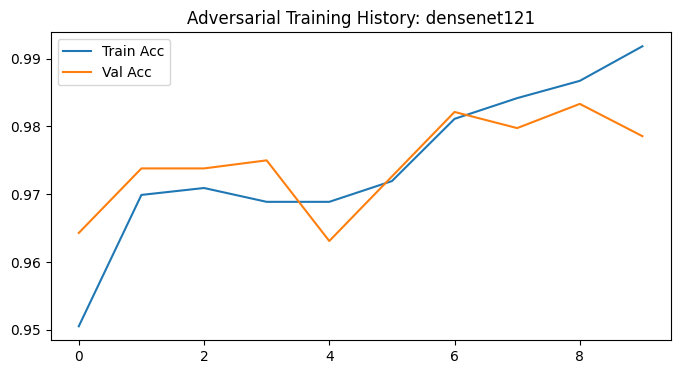


TRAINING ADVERSARIAL MODEL: resnet50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 183MB/s]
Epoch 1 [Train]: 100%|██████████| 62/62 [01:06<00:00,  1.08s/it]


Result -> Train Acc: 0.9653 | Val Acc: 0.9726
 Saved New Best: /content/drive/MyDrive/models1/tumor_resnet50_adv.pth


Epoch 2 [Train]: 100%|██████████| 62/62 [01:06<00:00,  1.07s/it]


Result -> Train Acc: 0.9786 | Val Acc: 0.9607


...

Result -> Train Acc: 0.9939 | Val Acc: 0.9893


Epoch 9 [Train]: 100%|██████████| 62/62 [01:06<00:00,  1.07s/it]


Result -> Train Acc: 0.9908 | Val Acc: 0.9821


Epoch 10 [Train]: 100%|██████████| 62/62 [01:06<00:00,  1.07s/it]


Result -> Train Acc: 0.9954 | Val Acc: 0.9810


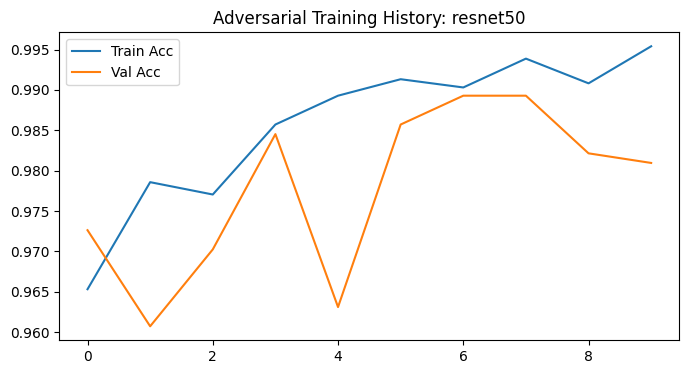


 Adversarial Training Phase Complete. 


In [6]:
from tqdm import tqdm

# --- 1. SETTINGS ---
EPSILON = 0.01
MODELS_TO_TRAIN = ["densenet121", "resnet50"]
EPOCHS = 10
min_clip, max_clip = get_clipping_bounds(DEVICE)

# --- 2. THE ADVERSARIAL ENGINE ---
for m_name in MODELS_TO_TRAIN:
    print(f"\n" + "="*40)
    print(f"TRAINING ADVERSARIAL MODEL: {m_name}")
    print("="*40)

    # Initialize model, optimizer, and criterion
    model = build_model(m_name, len(class_names))
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0.0
    history = {"train_acc": [], "val_acc": []}

    for epoch in range(EPOCHS):
        # --- TRAINING PHASE ---
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0

        for images, labels in tqdm(loaders['train'], desc=f"Epoch {epoch+1} [Train]"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            # 1. Clean Pass
            outputs = model(images)
            loss_clean = criterion(outputs, labels)

            # 2. Generate Adversarial Images
            adv_images = fgsm_attack(model, images, labels, EPSILON, min_clip, max_clip)

            # 3. Adversarial Pass
            adv_outputs = model(adv_images)
            loss_adv = criterion(adv_outputs, labels)

            # 4. Combined Loss
            loss = 0.5 * loss_clean + 0.5 * loss_adv

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        # --- VALIDATION PHASE ---
        model.eval()
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in loaders['validation']:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        epoch_train_acc = train_correct / train_total
        epoch_val_acc = val_correct / val_total

        history["train_acc"].append(epoch_train_acc)
        history["val_acc"].append(epoch_val_acc)

        print(f"Result -> Train Acc: {epoch_train_acc:.4f} | Val Acc: {epoch_val_acc:.4f}")

        # Save Best Model
        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            save_path = os.path.join(SAVE_DIR, f"tumor_{m_name}_adv.pth")
            torch.save({
                'model_state_dict': model.state_dict(),
                'class_to_idx': {class_names[0]: 0, class_names[1]: 1},
                'model_name': m_name,
                'type': 'adversarial'
            }, save_path)
            print(f" Saved New Best: {save_path}")

    # Plot results
    plt.figure(figsize=(8, 4))
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.title(f"Adversarial Training History: {m_name}")
    plt.legend()
    plt.show()

print("\n Adversarial Training Phase Complete. ")

In [8]:
def test_clean(model, loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

def test_adversarial(model, loader, epsilon, min_clip, max_clip):
    model.eval()

    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        # Generate adversarial images
        adv_images = fgsm_attack(model, images, labels, epsilon, min_clip, max_clip)

        # Test on adversarial images
        outputs = model(adv_images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = correct / total
    return acc

models_to_test = ["resnet50", "densenet121"]

epsilon = 16/255
min_clip, max_clip = get_clipping_bounds(DEVICE)

for m_name in models_to_test:

    print(f"\nTesting {m_name}")

    # Load model
    model = build_model(m_name, len(class_names))

    checkpoint = torch.load(os.path.join(SAVE_DIR, f"tumor_{m_name}_adv.pth"))
    model.load_state_dict(checkpoint["model_state_dict"])

    # Test
    clean_acc = test_clean(model, loaders["validation"])
    adv_acc = test_adversarial(model, loaders["validation"], epsilon, min_clip, max_clip)

    print(f"Clean Accuracy: {clean_acc:.4f}")
    print(f"Adversarial Accuracy: {adv_acc:.4f}")


Testing resnet50
Clean Accuracy: 0.9893
Adversarial Accuracy: 0.8536

Testing densenet121
Clean Accuracy: 0.9833
Adversarial Accuracy: 0.8690
